# 40 — Detection evaluation

A detector returns a variable number of scored boxes. Unlike classification, there is no fixed row-by-row correspondence between predictions and targets. Evaluation must first decide which predictions match which ground-truth objects.

In this notebook we will:

- rank detections by confidence;
- match predictions to ground truth using class labels and IoU;
- enforce one prediction per ground-truth object;
- count true positives, false positives, and false negatives;
- construct a precision–recall curve;
- calculate interpolated Average Precision (AP);
- compare IoU thresholds and calculate a simplified mean AP.

We use one synthetic image so every decision can be checked manually. This teaches the core mechanics, not the complete COCO evaluation protocol.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

from cs231n_practice.detection import pairwise_box_iou

np.set_printoptions(precision=3, suppress=True)
CLASS_NAMES = np.array(["cat", "dog"])

## 1. Predictions do not arrive aligned with targets

The image contains three ground-truth objects. Seven predictions include good detections, a duplicate, a wrong-class box, and background false alarms. Predictions are already ordered here for readability, but an evaluator must explicitly sort them by descending confidence.

A geometrically perfect overlap is not a correct detection when the predicted class is wrong. Conversely, a correct class is not enough when localization overlap is below the required IoU threshold.

### Exercise 1 — Inspect geometric and semantic compatibility

Calculate the prediction-to-target IoU matrix and a Boolean class-compatibility matrix.

In [6]:
ground_truth_boxes = np.array([
    [10.0, 10.0, 50.0, 50.0],
    [65.0, 15.0, 105.0, 55.0],
    [20.0, 58.0, 55.0, 78.0],
])
ground_truth_labels = np.array([0, 1, 0])

predicted_boxes = np.array([
    [9.0, 9.0, 51.0, 51.0],      # good cat around target 0
    [12.0, 12.0, 49.0, 49.0],    # duplicate cat around target 0
    [66.0, 16.0, 104.0, 54.0],   # good dog around target 1
    [20.0, 58.0, 55.0, 78.0],    # perfect geometry, wrong class
    [18.0, 57.0, 56.0, 79.0],    # good cat around target 2
    [75.0, 60.0, 105.0, 78.0],   # background cat false alarm
    [0.0, 60.0, 18.0, 78.0],     # background dog false alarm
])
predicted_scores = np.array([0.95, 0.90, 0.85, 0.75, 0.70, 0.55, 0.40])
predicted_labels = np.array([0, 0, 1, 1, 0, 0, 1])

# calculate every prediction-target IoU.
overlaps = pairwise_box_iou(predicted_boxes, ground_truth_boxes)
# compare every predicted label with every target label.
same_class = predicted_labels[:, np.newaxis] == ground_truth_labels

assert overlaps.shape == same_class.shape == (7, 3)
assert same_class.dtype == np.bool_
assert overlaps[3, 2] == 1.0
assert not same_class[3, 2]
assert np.argmax(overlaps[0]) == 0
assert np.argmax(overlaps[2]) == 1
print("IoU matrix:\n", overlaps)
print("Same-class matrix:\n", same_class.astype(int))

IoU matrix:
 [[0.907 0.    0.   ]
 [0.856 0.    0.   ]
 [0.    0.902 0.   ]
 [0.    0.    1.   ]
 [0.    0.    0.837]
 [0.    0.    0.   ]
 [0.    0.    0.   ]]
Same-class matrix:
 [[1 0 1]
 [1 0 1]
 [0 1 0]
 [0 1 0]
 [1 0 1]
 [1 0 1]
 [0 1 0]]


## 2. Greedy class-aware matching

At a chosen IoU threshold, evaluate predictions from highest to lowest confidence. A prediction is a true positive only if it finds an **unmatched** ground-truth box with the same class and sufficient IoU. Otherwise it is a false positive.

Each ground-truth object may be matched only once. This rule makes a duplicate prediction a false positive even when it has excellent overlap. Without it, a detector could receive extra credit for reporting the same object repeatedly.

After all predictions are processed, every unmatched ground-truth object is a false negative. Therefore:

```text
TP = matched predictions
FP = unmatched predictions
FN = unmatched ground-truth objects
```

### Exercise 2 — Match predictions to targets

Return prediction order, a true-positive mask in ranked order, and matched ground-truth indices. Store `-1` when a prediction has no match.

In [7]:
(
    same_class[0],
    np.zeros(len(ground_truth_boxes), dtype=bool),
    same_class[0] & ~np.zeros(len(ground_truth_boxes), dtype=bool),
    np.array([True, False, True]) & ~np.array([False, False, True]),
    np.flatnonzero(np.array([True, False, True]) & ~np.array([False, False, True])),
    np.flatnonzero(np.array([True, False, True]) & np.array([False, False, True])),
)


(array([ True, False,  True]),
 array([False, False, False]),
 array([ True, False,  True]),
 array([ True, False, False]),
 array([0]),
 array([2]))

In [8]:
def match_detections(
    predicted_boxes, predicted_scores, predicted_labels,
    target_boxes, target_labels, iou_threshold,
):
    """Greedily match ranked predictions to same-class targets."""
    # sort prediction indices from highest to lowest score.
    order = np.argsort(-predicted_scores, kind="stable")
    pairwise_ious = pairwise_box_iou(predicted_boxes, target_boxes)
    target_matched = np.zeros(len(target_boxes), dtype=bool)
    true_positive = np.zeros(len(predicted_boxes), dtype=bool)
    matched_target = np.full(len(predicted_boxes), -1, dtype=np.int64)
    same_class = predicted_labels[:, np.newaxis] == target_labels

    for rank, prediction_index in enumerate(order):
        # allow only targets with the same class that are still unmatched.
        eligible = (same_class[prediction_index] & ~target_matched)
        eligible_indices = np.flatnonzero(eligible)
        if eligible_indices.size == 0:
            continue

        eligible_ious = pairwise_ious[prediction_index, eligible_indices]
        # select the eligible target with maximum IoU.
        best_target = eligible_indices[np.argmax(eligible_ious)]
        if pairwise_ious[prediction_index, best_target] >= iou_threshold:
            # record the TP and prevent this target from matching again.
            true_positive[rank] = True
            matched_target[rank] = best_target
            target_matched[best_target] = True

    return order, true_positive, matched_target

order, true_positive, matched_target = match_detections(
    predicted_boxes, predicted_scores, predicted_labels,
    ground_truth_boxes, ground_truth_labels, iou_threshold=0.5,
)
np.testing.assert_array_equal(order, np.arange(7))
np.testing.assert_array_equal(true_positive, [True, False, True, False, True, False, False])
np.testing.assert_array_equal(matched_target, [0, -1, 1, -1, 2, -1, -1])
false_positive = ~true_positive
false_negative_count = len(ground_truth_boxes) - true_positive.sum()
assert (true_positive.sum(), false_positive.sum(), false_negative_count) == (3, 4, 0)
print("TP by rank:", true_positive.astype(int))
print("Matched target:", matched_target)

TP by rank: [1 0 1 0 1 0 0]
Matched target: [ 0 -1  1 -1  2 -1 -1]


## 3. Precision and recall across confidence ranks

Instead of choosing one confidence threshold, sort the predictions from highest to lowest confidence and inspect progressively longer prefixes of that list. Rank $k$ means that we keep the first $k$ predictions and temporarily ignore every prediction below them. This is equivalent to gradually lowering the confidence threshold.

$$\mathrm{precision}_k = \frac{\mathrm{TP}_{1:k}}{k},$$

$$\mathrm{recall}_k = \frac{\mathrm{TP}_{1:k}}{N_{gt}}.$$

Here:

- $\mathrm{TP}_{1:k}$ is the **cumulative** number of true positives among ranked predictions 1 through $k$; it is a count, not a slice of boxes;
- $k$ is the number of predictions considered so far;
- $N_{gt}$ is the total number of ground-truth objects that could be found. In this example, $N_{gt}=3$.

For example, suppose matching produces the ranked TP/FP decisions

$$[1, 0, 1, 0, 1, 0, 0],$$

where 1 means TP and 0 means FP. Their cumulative TP counts are

$$[1, 1, 2, 2, 3, 3, 3].$$

At rank 3, we have accepted three predictions and two of them are correct, so precision is $2/3$. Those two predictions found two of the three ground-truth objects, so recall is also $2/3$. At rank 4, the new prediction is an FP: cumulative TP remains 2, precision falls to $2/4$, and recall remains $2/3$.

The implementation follows exactly these steps:

1. `np.cumsum(true_positive)` calculates $\mathrm{TP}_{1:k}$ for every rank.
2. `np.arange(1, M + 1)` creates the ranks $[1, 2, \ldots, M]$, which are the precision denominators.
3. Divide cumulative TP by the ranks to get precision.
4. Divide cumulative TP by the fixed number of targets $N_{gt}$ to get recall.

Therefore, a TP increases recall and may increase precision, whereas an FP leaves recall unchanged and decreases precision. Confidence scores determine the ranking—and thus the order in which points appear—but the precision and recall values are calculated from the resulting TP/FP decisions. Each rank produces one point $(\mathrm{recall}_k, \mathrm{precision}_k)$ on the precision–recall curve.

### Exercise 3 — Construct and visualize the precision–recall curve

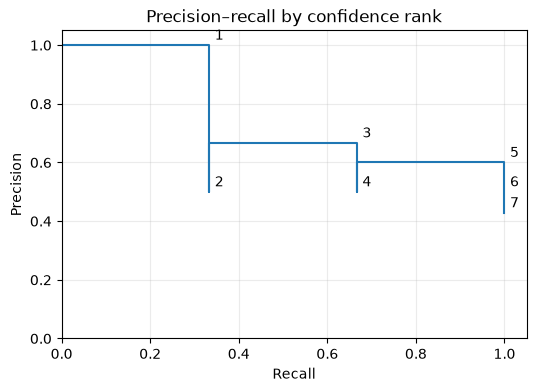

In [10]:
def precision_recall_from_matches(true_positive, number_of_targets):
    """Return precision and recall after every ranked prediction."""
    true_positive = np.asarray(true_positive, dtype=bool)
    # calculate cumulative TP, prediction ranks 1..M, precision, recall.
    cumulative_true_positive = np.cumsum(true_positive)
    prediction_count = np.arange(1, len(true_positive) + 1)
    precision = cumulative_true_positive / prediction_count
    recall = cumulative_true_positive / number_of_targets
    return precision, recall

precision, recall = precision_recall_from_matches(
    true_positive, len(ground_truth_boxes)
)
np.testing.assert_allclose(precision, [1, 1/2, 2/3, 1/2, 3/5, 1/2, 3/7])
np.testing.assert_allclose(recall, [1/3, 1/3, 2/3, 2/3, 1, 1, 1])

fig, axis = plt.subplots(figsize=(6, 4))
axis.step(np.r_[0, recall], np.r_[1, precision], where="pre") # , where="post" , where="mid"
for rank, (x, y) in enumerate(zip(recall, precision), start=1):
    axis.annotate(str(rank), (x, y), xytext=(4, 4), textcoords="offset points")
axis.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1.05),
         ylim=(0, 1.05), title="Precision–recall by confidence rank")
axis.grid(alpha=0.25)
plt.show()

## 4. Average Precision

Precision and recall give us several points—one after each ranked prediction. **Average Precision (AP)** converts the complete precision–recall curve into one number between 0 and 1. Intuitively, it measures how much of the recall range is covered while precision remains high. A perfect detector has AP equal to 1.

$$\mathrm{AP}=\sum_k (r_k-r_{k-1})p_{envelope,k}.$$

This formula is the area of a collection of rectangles:

- $r_k-r_{k-1}$ is the rectangle's **width**: the amount by which recall increased;
- $p_{envelope,k}$ is its **height**: the interpolated precision at the new recall level;
- adding width times height gives the total area under the curve.

### Why create a precision envelope?

Raw precision can move both down and up. For example, an FP may reduce precision and a later TP may improve it again. Interpolated AP uses the best precision achieved at the current recall or at any greater recall:

$$p_{envelope}(r)=\max_{\tilde r \ge r}p(\tilde r).$$

Here $\tilde r$ means any recall value at or to the right of $r$. In an array, we therefore scan precision **from right to left** and replace each value with the maximum seen so far. The resulting envelope cannot increase as recall moves from left to right.

For this notebook, the raw values from Section 3 are:

```text
rank:       1     2     3     4     5     6     7
TP/FP:      TP    FP    TP    FP    TP    FP    FP
recall:     1/3   1/3   2/3   2/3   1     1     1
precision:  1     1/2   2/3   1/2   3/5   1/2   3/7
```

At recall $1/3$, later points with the same or greater recall include precision $2/3$, but none is better than the original precision 1, so the envelope height is 1. At recall $2/3$, the best current-or-later precision is $2/3$. At recall 1, the best precision reached there is $3/5$.

Recall increases only three times: from 0 to $1/3$, from $1/3$ to $2/3$, and from $2/3$ to 1. Therefore AP is the area of three rectangles:

$$
\begin{aligned}
\mathrm{AP}
&= \left(\frac{1}{3}-0\right)(1)
 + \left(\frac{2}{3}-\frac{1}{3}\right)\left(\frac{2}{3}\right)
 + \left(1-\frac{2}{3}\right)\left(\frac{3}{5}\right) \\
&= \frac{1}{3}+\frac{2}{9}+\frac{1}{5}
 = \frac{34}{45}
 \approx 0.756.
\end{aligned}
$$

The repeated recall values do not create additional area because their width is zero. They correspond to false positives: an FP finds no new ground-truth object, so recall does not increase. However, FPs still matter because they reduce precision and can lower the envelope used for later recall intervals. This is also why changing confidence scores—and therefore the prediction order—can change AP.

### How the implementation maps to the idea

1. Add sentinel endpoints so the curve starts at recall 0 and is defined through recall 1.
2. Scan `extended_precision` from right to left and store the maximum precision seen so far.
3. Find indices where consecutive recall values differ; only those positions have nonzero rectangle width.
4. Multiply every recall increase by its envelope precision and sum the areas.

### Exercise 4 — Implement interpolated AP

AP@0.50: 0.756


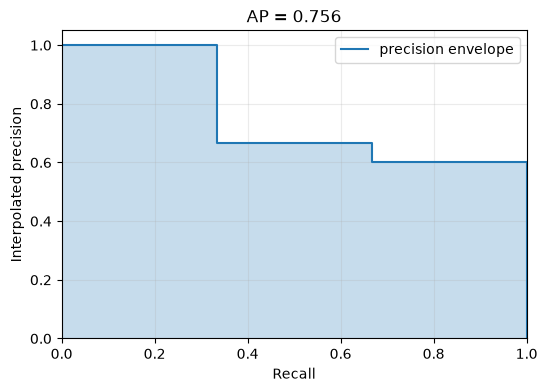

In [25]:
def interpolated_average_precision(precision, recall):
    """Calculate area under the all-point interpolated PR curve."""
    precision = np.asarray(precision, dtype=float)
    recall = np.asarray(recall, dtype=float)
    # Sentinels define curve behavior before the first and after the last point.
    extended_precision = np.r_[0.0, precision, 0.0]
    extended_recall = np.r_[0.0, recall, 1.0]

    # scan from right to left so each position stores the best
    # precision available at that recall or any greater recall.
    for index in range(len(extended_precision) - 2, -1, -1):
        extended_precision[index] = max(
            extended_precision[index], extended_precision[index + 1]
        )

    # find positions where recall increases and sum rectangular areas.
    recall_increase = extended_recall[1:] - extended_recall[:-1]
    changing_recall = recall_increase > 0
    average_precision = np.sum(
        recall_increase[changing_recall]
        * extended_precision[1:][changing_recall]
    )
    return float(average_precision), extended_recall, extended_precision

average_precision, envelope_recall, envelope_precision = (
    interpolated_average_precision(precision, recall)
)
np.testing.assert_allclose(average_precision, 34.0 / 45.0)
assert 0.0 <= average_precision <= 1.0
print(f"AP@0.50: {average_precision:.3f}")

fig, axis = plt.subplots(figsize=(6, 4))
axis.step(envelope_recall, envelope_precision, where="post", label="precision envelope")
axis.fill_between(envelope_recall, envelope_precision, step="post", alpha=0.25)
axis.set(xlabel="Recall", ylabel="Interpolated precision",
         xlim=(0, 1), ylim=(0, 1.05), title=f"AP = {average_precision:.3f}")
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## 5. IoU threshold changes what counts as correct

A stricter IoU threshold demands more accurate localization. The confidence scores and boxes do not change, but the TP/FP assignments can. `AP@0.50` and `AP@0.75` therefore evaluate the same ranked detections under different localization requirements.

### Exercise 5 — Compare several matching thresholds

For each threshold, rematch from scratch. Ground-truth match state must never be reused across thresholds.

In [26]:
threshold_results = []
for threshold in [0.50, 0.75, 0.90, 0.95]:
    _, threshold_tp, _ = match_detections(
        predicted_boxes, predicted_scores, predicted_labels,
        ground_truth_boxes, ground_truth_labels, threshold,
    )
    # calculate precision, recall, and AP for this new matching.
    threshold_precision, threshold_recall = precision_recall_from_matches(
        threshold_tp, len(ground_truth_boxes)
    )
    threshold_ap, _, _ = interpolated_average_precision(threshold_precision, threshold_recall)
    threshold_results.append((threshold, threshold_tp.sum(), threshold_ap))

assert [result[1] for result in threshold_results] == [3, 3, 2, 0]
np.testing.assert_allclose(
    [result[2] for result in threshold_results],
    [34/45, 34/45, 5/9, 0],
)
for threshold, tp_count, ap in threshold_results:
    print(f"IoU={threshold:.2f}: TP={tp_count}, AP={ap:.3f}")

IoU=0.50: TP=3, AP=0.756
IoU=0.75: TP=3, AP=0.756
IoU=0.90: TP=2, AP=0.556
IoU=0.95: TP=0, AP=0.000


## 6. From AP to mean Average Precision

AP is normally calculated independently for each class because confidence rankings and matching are class-specific. Mean Average Precision (mAP) averages those class AP values. In larger benchmarks it may also be averaged across multiple IoU thresholds.

Our simplified `mAP@0.50` is

$$\mathrm{mAP@0.50}=\frac{1}{C}\sum_{c=1}^{C}\mathrm{AP}_c@0.50.$$

### Exercise 6 — Calculate AP separately for cats and dogs

Subset both predictions and targets by class, run matching, calculate the class PR curve, and average the resulting AP values.

In [20]:
class_average_precisions = []
for class_index, class_name in enumerate(CLASS_NAMES):
    prediction_mask = predicted_labels == class_index
    target_mask = ground_truth_labels == class_index
    class_boxes = predicted_boxes[prediction_mask]
    class_scores = predicted_scores[prediction_mask]
    class_labels = predicted_labels[prediction_mask]
    class_target_boxes = ground_truth_boxes[target_mask]
    class_target_labels = ground_truth_labels[target_mask]

    # match this class, calculate its PR curve, and calculate AP.
    _, class_tp, _ = match_detections(
        class_boxes, class_scores, class_labels,
        class_target_boxes, class_target_labels, iou_threshold=0.5,
    )
    class_precision, class_recall = precision_recall_from_matches(
        class_tp, len(class_target_boxes)
    )
    class_ap, _, _ = interpolated_average_precision(class_precision, class_recall)
    class_average_precisions.append(class_ap)
    print(f"{class_name}: AP@0.50={class_ap:.3f}")

mean_average_precision = np.mean(class_average_precisions)
np.testing.assert_allclose(class_average_precisions, [5.0 / 6.0, 1.0])
np.testing.assert_allclose(mean_average_precision, 11.0 / 12.0)
print(f"mAP@0.50={mean_average_precision:.3f}")

cat: AP@0.50=0.833
dog: AP@0.50=1.000
mAP@0.50=0.917


### Why is dog AP equal to 1 with three dog predictions?

Only the first dog prediction is correct. In confidence order, the dog decisions are `[TP, FP, FP]`. Because there is one dog ground-truth object, the first prediction immediately reaches recall 1 with precision 1. The later false positives lower precision to $1/2$ and then $1/3$, but recall stays at 1. They therefore have zero recall width and add no new area to the AP calculation.

Thus, AP equal to 1 does **not** mean that every prediction is correct. Here it means that the only correct dog detection was ranked before both incorrect dog detections. If an FP had been ranked before the TP, dog AP would be lower.

In [21]:
(
    predicted_labels,
    predicted_scores,
)


(array([0, 0, 1, 1, 0, 0, 1]),
 array([0.95, 0.9 , 0.85, 0.75, 0.7 , 0.55, 0.4 ]))

## 7. What this simplified example leaves out

Real evaluation aggregates detections across many images before building each class ranking. Matches are still restricted to ground truths in the same image. Benchmarks also define policies for ignored annotations, crowd regions, object sizes, maximum detections, interpolation, and averaging.

The COCO headline metric averages AP across IoU thresholds from 0.50 through 0.95, not just classes at one threshold. Therefore, always state the metric convention rather than reporting the ambiguous word `mAP` alone.

## Reflection

Answer briefly in your own words.

1. Why must detections be ranked by confidence before evaluation?
2. What two conditions must a prediction satisfy to match a ground-truth object?
3. Why can each ground-truth object be matched only once?
4. Why is the duplicate prediction at rank 2 a false positive?
5. Why is prediction 3 a true positive while prediction 4 is a false positive, despite prediction 4 having perfect geometric overlap?
6. How does a false positive affect precision and recall?
7. Why can AP change when prediction scores change even if boxes and labels do not?
8. What happens as the matching IoU threshold becomes stricter?
9. What is averaged in this notebook's mAP, and how is the COCO headline metric broader?

### Answers

1. there might be multiple detection of the same object. sometimes we discard all detection below confidence threshold. Detections must be ranked by confidence so evaluation can progressively lower the confidence threshold. This rewards detectors that rank correct detections before false positives.
2. same class, sufficient IoU, and the target must still be unmatched.
3. if not the model might just predict multiple detection to improve metrics
4. cause detection at earlier rank predicted the same label and matched ground truth boundary box
5. 3 is first prediction of dog and it is ok (IoU match with ground truth). 4 has wrong class prediction
6. recall stays the same, precision gets worse
7. Scores determine the order of predictions. Changing that order changes where true and false positives occur on the precision–recall curve, so AP can change even if boxes and labels stay unchanged.
8. there are less positive predictions, recall might become smaller. A stricter IoU threshold may turn previous true positives into false positives. This can reduce maximum recall and usually lowers or preserves AP.
9. This notebook averages the separate cat and dog AP values. COCO additionally averages across IoU thresholds from 0.50 to 0.95. Predictions from multiple images are aggregated by class before each AP is calculated.